In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print(torch.cuda.is_available())

False


## 1. Data Download and Exploration


In [2]:
import kagglehub
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print(path)
print(os.listdir(path))

C:\Users\Üzeyir\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2
['seg_pred', 'seg_test', 'seg_train']


In [3]:
train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir  = os.path.join(path, "seg_test", "seg_test")
pred_dir  = os.path.join(path, "seg_pred", "seg_pred")

for d in [train_dir, test_dir]:
    print(d)
    for cls in sorted(os.listdir(d)):
        print("  ", cls, len(os.listdir(os.path.join(d, cls))))

C:\Users\Üzeyir\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train
   buildings 2191
   forest 2271
   glacier 2404
   mountain 2512
   sea 2274
   street 2382
C:\Users\Üzeyir\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test
   buildings 437
   forest 474
   glacier 553
   mountain 525
   sea 510
   street 501


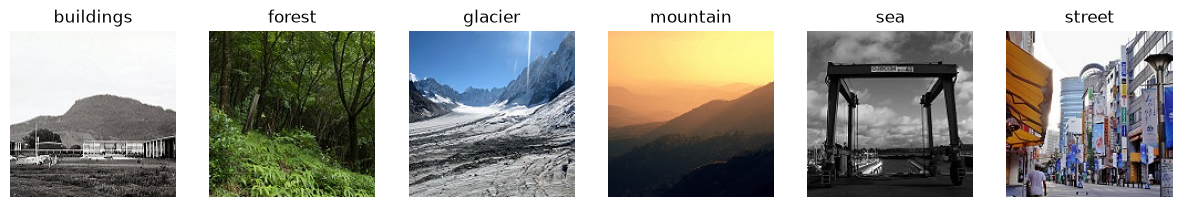

In [4]:
from PIL import Image

classes = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

plt.figure(figsize=(15, 3))
position = 1

for name in classes:
    
    folder = train_dir + "/" + name

    files = os.listdir(folder)

    image = Image.open(folder + "/" + files[0])

    plt.subplot(1, 6, position)

    plt.imshow(image)
    plt.title(name)
    plt.axis("off")

    position = position + 1
plt.show()

## 2. Preprocessing and Normalization

In [5]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = datasets.ImageFolder(train_dir, transform=transform)
test_data = datasets.ImageFolder(test_dir, transform=transform)

print(len(train_data))
print(len(test_data))
print(train_data.class_to_idx)

14034
3000
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [6]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

generator = torch.Generator().manual_seed(42)

train_part, val_part = random_split(train_data, [train_size, val_size], generator=generator)

print("train:", len(train_part))
print("validation:", len(val_part))
print("test:", len(test_data))

train: 11227
validation: 2807
test: 3000


### DataLoader

In [7]:
batch_size = 32

train_loader = DataLoader(train_part, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_part, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("train batch :", len(train_loader))
print("validation batch :", len(val_loader))
print("test batch :", len(test_loader))

train batch : 351
validation batch : 88
test batch : 94


## 3. Visualizing a Batch of Training Data


torch.Size([32, 3, 150, 150])
tensor([3, 5, 4, 5, 4, 5, 4, 3, 2, 3])


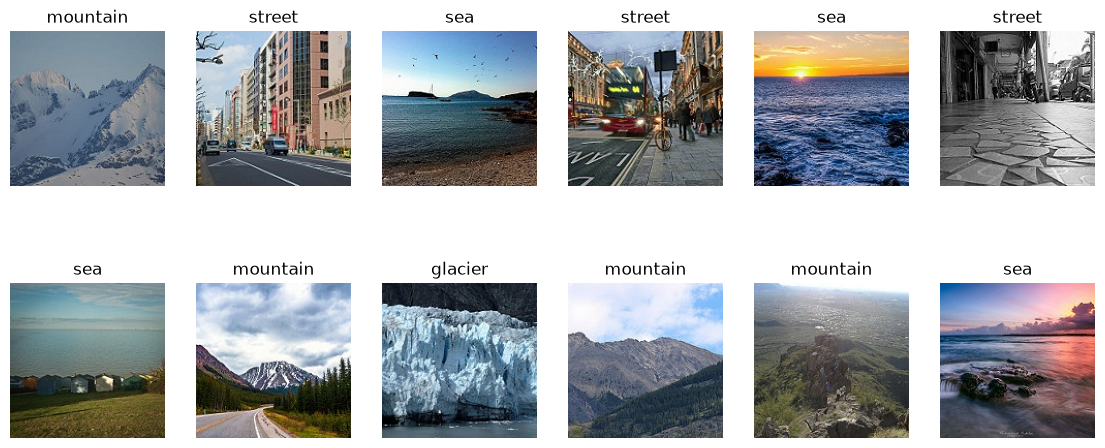

In [8]:
# loader take first Batch
images, labels = next(iter(train_loader))

print(images.shape)
print(labels[:10])

class_names = train_data.classes

plt.figure(figsize=(14, 6))

for i in range(12):
    image = images[i]

    # Undo Normalize 
    image = image * 0.5 + 0.5

    # matplotlib asks that
    image = image.permute(1, 2, 0)

    plt.subplot(2, 6, i + 1)
    plt.imshow(image)

    # number to label ex 1-> 'forest'
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

## 4. Model, Loss Function and Optimizer


In [9]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*18*18,128)
        self.fc2 = nn.Linear(128,6)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=20736, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)


### Loss və optimizer

In [10]:
import torch.optim as optim

# Loss calculation Function
criterion = nn.CrossEntropyLoss()

# Adam optimizer
#  parameters() -> weights , bias etc
optimizer = optim.Adam(model.parameters(), lr=0.001)


# test: bir batch ver, çıxışın formasına bax
images, labels = next(iter(train_loader))
outputs = model(images)
print(outputs.shape)

torch.Size([32, 6])


In [11]:
print(outputs[0])
print("modelin təxmini:", outputs[0].argmax().item())
print("düzgün cavab:", labels[0].item())

tensor([-0.0317, -0.0570,  0.1069,  0.0117,  0.0733,  0.0905],
       grad_fn=<SelectBackward0>)
modelin təxmini: 2
düzgün cavab: 3


In [12]:
# 1. batch
images, labels = next(iter(train_loader))

# 2. delete previous calculation grad
optimizer.zero_grad()

# 3. model pred
outputs = model(images)

# 4. calculate loss
loss = criterion(outputs, labels)
print("before train:", loss.item())

# 5. every weight effect for error
loss.backward()

# 6. rearrange weights
optimizer.step()

# 7. check same batch
outputs = model(images)
loss = criterion(outputs, labels)
print("after train:", loss.item())

before train: 1.826373815536499
after train: 1.6054441928863525


In [13]:
import time

epochs = 3

# to keep minimum loss
best_val_loss = 999

# create model folder 
os.makedirs("models", exist_ok=True)

for epoch in range(epochs):
    start = time.time()

    # ---------- Train ----------
    model.train()
    train_loss_sum = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum = train_loss_sum + loss.item()

    # avg loss = sum / number of batches
    train_loss = train_loss_sum / len(train_loader)

    # ---------- Check ----------
    model.eval()
    val_loss_sum = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_sum = val_loss_sum + loss.item()

            # model pred
            predictions = outputs.argmax(dim=1)

            # number of correct pred
            correct = correct + (predictions == labels).sum().item()
            total = total + labels.size(0)

    val_loss = val_loss_sum / len(val_loader)
    val_accuracy = 100 * correct / total

    # ---------- result ----------
    seconds = time.time() - start
    print("Epoch", epoch + 1, "/", epochs)
    print("  train loss:", round(train_loss, 4))
    print("  val loss:", round(val_loss, 4))
    print("  val accuracy:", round(val_accuracy, 2), "%")
    print("  time:", round(seconds), "sec")

    # ---------- keep best model ----------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "models/best_model.pth")
        print("  -> best model")

Epoch 1 / 3
  train loss: 0.916
  val loss: 0.7043
  val accuracy: 74.03 %
  time: 111 sec
  -> best model
Epoch 2 / 3
  train loss: 0.6154
  val loss: 0.5865
  val accuracy: 78.62 %
  time: 97 sec
  -> best model
Epoch 3 / 3
  train loss: 0.463
  val loss: 0.5537
  val accuracy: 79.55 %
  time: 95 sec
  -> best model


### load model from file

In [14]:
# empty model
model = SimpleCNN()

# upload file weight to this empty model
model.load_state_dict(torch.load("models/best_model.pth"))

# check
model.eval()

print("Model uploaded")

Model uploaded


In [15]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        correct = correct + (predictions == labels).sum().item()
        total = total + labels.size(0)

test_accuracy = 100 * correct / total
print("Test accuracy:", round(test_accuracy, 2), "%")

Test accuracy: 81.07 %


In [16]:
class_names = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

# 2 counter for each class, coreect size and all count
class_correct = [0, 0, 0, 0, 0, 0]
class_total = [0, 0, 0, 0, 0, 0]

with torch.no_grad(): 
    for images, labels in test_loader:
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        #check every pic in batch
        for i in range(len(labels)):
            true_label = labels[i].item()
            class_total[true_label] = class_total[true_label] + 1

            if predictions[i] == labels[i]:
                class_correct[true_label] = class_correct[true_label] + 1

for i in range(6):
    accuracy = 100 * class_correct[i] / class_total[i]
    print(class_names[i], ":", round(accuracy, 1), "%")

buildings : 65.7 %
forest : 94.3 %
glacier : 82.8 %
mountain : 79.2 %
sea : 75.1 %
street : 88.0 %


In [17]:
# 6x6 empty
matrix = torch.zeros(6, 6)

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        for i in range(len(labels)):
            true_label = labels[i].item()
            predicted_label = predictions[i].item()
            matrix[true_label][predicted_label] = matrix[true_label][predicted_label] + 1

print(matrix)

tensor([[287.,  13.,   9.,  16.,  18.,  94.],
        [  0., 447.,   4.,   9.,   4.,  10.],
        [  7.,   3., 458.,  59.,  21.,   5.],
        [  3.,   1.,  74., 416.,  31.,   0.],
        [ 13.,   3.,  62.,  41., 383.,   8.],
        [ 23.,  12.,   9.,   5.,  11., 441.]])


## 5. Training (Baseline, 10 Epochs, Data Augmentation)

In [18]:
# new model və new optimizer
model = SimpleCNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
best_val_loss = 999

# empty lists for graphics
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    start = time.time()

    # ---------- Train ----------
    model.train()
    train_loss_sum = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss_sum = train_loss_sum + loss.item()

    train_loss = train_loss_sum / len(train_loader)

    # ---------- Check ----------
    model.eval()
    val_loss_sum = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_sum = val_loss_sum + loss.item()

            predictions = outputs.argmax(dim=1)
            correct = correct + (predictions == labels).sum().item()
            total = total + labels.size(0)

    val_loss = val_loss_sum / len(val_loader)
    val_accuracy = 100 * correct / total

    # ---------- Add results to list ----------
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # ---------- Print to Screen ----------
    seconds = time.time() - start
    print("Epoch", epoch + 1, "/", epochs)
    print("  train loss:", round(train_loss, 4))
    print("  val loss:", round(val_loss, 4))
    print("  val accuracy:", round(val_accuracy, 2), "%")
    print("  time:", round(seconds), "sec")

    # ---------- Keep best model ----------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "models/best_model_10.pth")
        print("  -> kept best")

Epoch 1 / 10
  train loss: 0.9116
  val loss: 0.8076
  val accuracy: 69.47 %
  time: 98 sec
  -> kept best
Epoch 2 / 10
  train loss: 0.6044
  val loss: 0.6263
  val accuracy: 77.48 %
  time: 93 sec
  -> kept best
Epoch 3 / 10
  train loss: 0.4476
  val loss: 0.5833
  val accuracy: 78.73 %
  time: 93 sec
  -> kept best
Epoch 4 / 10
  train loss: 0.331
  val loss: 0.5551
  val accuracy: 79.62 %
  time: 92 sec
  -> kept best
Epoch 5 / 10
  train loss: 0.2173
  val loss: 0.6325
  val accuracy: 79.12 %
  time: 93 sec
Epoch 6 / 10
  train loss: 0.1236
  val loss: 0.8463
  val accuracy: 77.95 %
  time: 95 sec
Epoch 7 / 10
  train loss: 0.0863
  val loss: 0.8116
  val accuracy: 81.01 %
  time: 95 sec
Epoch 8 / 10
  train loss: 0.0558
  val loss: 1.0516
  val accuracy: 78.98 %
  time: 98 sec
Epoch 9 / 10
  train loss: 0.0523
  val loss: 1.1175
  val accuracy: 78.52 %
  time: 116 sec
Epoch 10 / 10
  train loss: 0.0308
  val loss: 1.016
  val accuracy: 79.34 %
  time: 177 sec


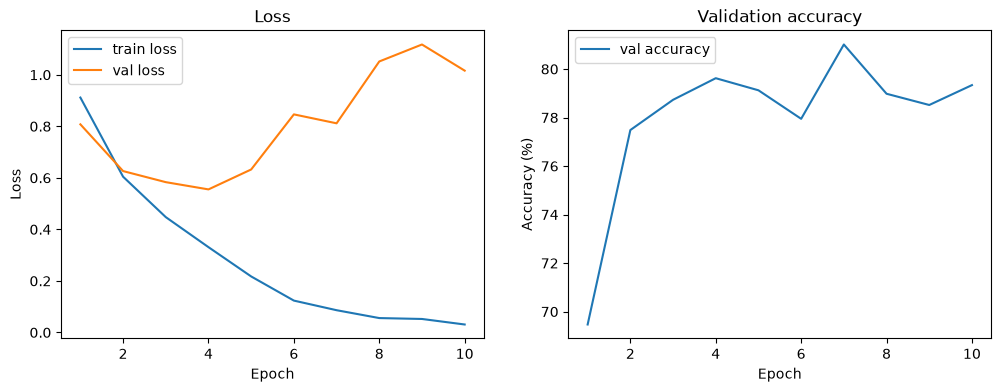

In [19]:
epoch_numbers = range(1, epochs + 1)

plt.figure(figsize=(12, 4))

# left side : loss
plt.subplot(1, 2, 1)
plt.plot(epoch_numbers, train_losses, label="train loss")
plt.plot(epoch_numbers, val_losses, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

# right side: accuracy
plt.subplot(1, 2, 2)
plt.plot(epoch_numbers, val_accuracies, label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation accuracy")
plt.legend()

plt.show()

### Data Augmentation

In [20]:
from torch.utils.data import Subset

# Adding random changes
train_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# read same folder twice : with & without augmentation
train_data_aug = datasets.ImageFolder(train_dir, transform=train_transform)
train_data_plain = datasets.ImageFolder(train_dir, transform=transform)

train_part_aug = Subset(train_data_aug, train_part.indices)
val_part_plain = Subset(train_data_plain, val_part.indices)

# Loaders
train_loader_aug = DataLoader(train_part_aug, batch_size=32, shuffle=True)
val_loader_plain = DataLoader(val_part_plain, batch_size=32, shuffle=False)

print("train:", len(train_part_aug))
print("validation:", len(val_part_plain))

train: 11227
validation: 2807


### Modelling with Augmentation 

In [21]:
model = SimpleCNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 15
best_val_loss = 999

train_losses_aug = []
val_losses_aug = []
val_accuracies_aug = []

for epoch in range(epochs):
    start = time.time()

    # ---------- Train----------
    model.train()
    train_loss_sum = 0

    for images, labels in train_loader_aug:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss_sum = train_loss_sum + loss.item()

    train_loss = train_loss_sum / len(train_loader_aug)

    # ---------- Check ----------
    model.eval()
    val_loss_sum = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader_plain:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_sum = val_loss_sum + loss.item()

            predictions = outputs.argmax(dim=1)
            correct = correct + (predictions == labels).sum().item()
            total = total + labels.size(0)

    val_loss = val_loss_sum / len(val_loader_plain)
    val_accuracy = 100 * correct / total

    # ---------- Add to the List ----------
    train_losses_aug.append(train_loss)
    val_losses_aug.append(val_loss)
    val_accuracies_aug.append(val_accuracy)

    # ---------- Print ----------
    seconds = time.time() - start
    print("Epoch", epoch + 1, "/", epochs)
    print("  train loss:", round(train_loss, 4))
    print("  val loss:", round(val_loss, 4))
    print("  val accuracy:", round(val_accuracy, 2), "%")
    print("  vaxt:", round(seconds), "sec")

    # ---------- Keep Best Model----------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "models/best_model_aug.pth")
        print("  -> Best Model Kept")

Epoch 1 / 15
  train loss: 0.9387
  val loss: 0.7407
  val accuracy: 72.03 %
  vaxt: 208 sec
  -> Best Model Kept
Epoch 2 / 15
  train loss: 0.6138
  val loss: 0.5334
  val accuracy: 80.48 %
  vaxt: 122 sec
  -> Best Model Kept
Epoch 3 / 15
  train loss: 0.529
  val loss: 0.5047
  val accuracy: 82.33 %
  vaxt: 109 sec
  -> Best Model Kept
Epoch 4 / 15
  train loss: 0.4758
  val loss: 0.5683
  val accuracy: 79.3 %
  vaxt: 103 sec
Epoch 5 / 15
  train loss: 0.4294
  val loss: 0.5007
  val accuracy: 81.44 %
  vaxt: 103 sec
  -> Best Model Kept
Epoch 6 / 15
  train loss: 0.3931
  val loss: 0.4565
  val accuracy: 84.22 %
  vaxt: 103 sec
  -> Best Model Kept
Epoch 7 / 15
  train loss: 0.3681
  val loss: 0.4548
  val accuracy: 83.15 %
  vaxt: 102 sec
  -> Best Model Kept
Epoch 8 / 15
  train loss: 0.3354
  val loss: 0.4402
  val accuracy: 84.75 %
  vaxt: 103 sec
  -> Best Model Kept
Epoch 9 / 15
  train loss: 0.3094
  val loss: 0.4697
  val accuracy: 84.57 %
  vaxt: 102 sec
Epoch 10 / 15
  tr

In [22]:
import shutil

pred_dir = path + "/seg_pred/seg_pred"
new_folder = path + "/pred_data/unknown"
os.makedirs(new_folder, exist_ok=True)

# All photos to new folder 
for file_name in os.listdir(pred_dir):
    shutil.copy(pred_dir + "/" + file_name, new_folder + "/" + file_name)

print(len(os.listdir(new_folder)))

7301


In [23]:
pred_data = datasets.ImageFolder(path + "/pred_data", transform=transform)
pred_loader = DataLoader(pred_data, batch_size=32, shuffle=False)
print(len(pred_data))

# final modeli upload
model = SimpleCNN()
model.load_state_dict(torch.load("models/best_model_aug.pth"))
model.eval()

all_predictions = []

with torch.no_grad():
    for images, _ in pred_loader:
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        all_predictions.extend(predictions.tolist())

class_names = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
for i in range(6):
    print(class_names[i], all_predictions.count(i))

7301
buildings 1171
forest 1156
glacier 1221
mountain 1289
sea 1254
street 1210


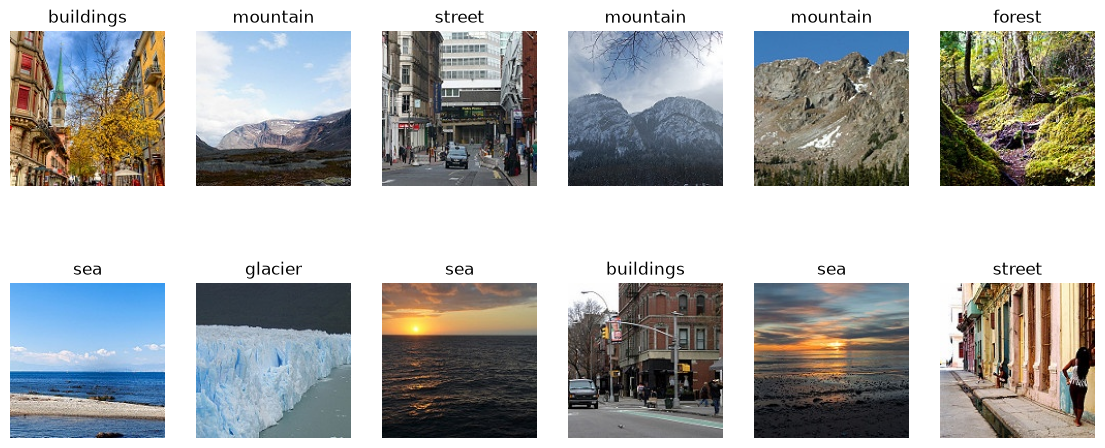

In [24]:
images, _ = next(iter(pred_loader))
with torch.no_grad():
    predictions = model(images).argmax(dim=1)

plt.figure(figsize=(14, 6))
for i in range(12):
    image = images[i] * 0.5 + 0.5
    image = image.permute(1, 2, 0)
    plt.subplot(2, 6, i + 1)
    plt.imshow(image)
    plt.title(class_names[predictions[i]])
    plt.axis("off")
plt.show()

## 6. Loading the Best Model


In [26]:
model = SimpleCNN()
model.load_state_dict(torch.load("models/best_model_aug.pth"))
model.eval()
print("Model Uploaded")

Model Uploaded


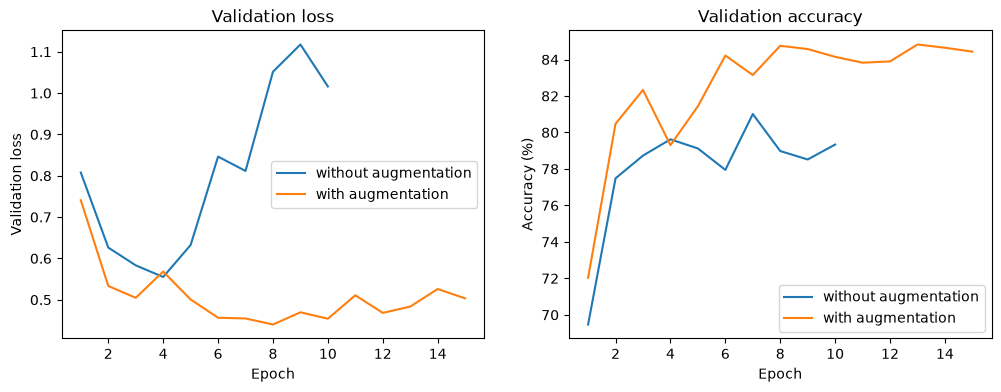

In [29]:
plt.figure(figsize=(12, 4))

#validation loss
plt.subplot(1, 2, 1)
plt.plot(range(1, len(val_losses) + 1), val_losses, label="without augmentation")
plt.plot(range(1, len(val_losses_aug) + 1), val_losses_aug, label="with augmentation")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss")
plt.legend()

#validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label="without augmentation")
plt.plot(range(1, len(val_accuracies_aug) + 1), val_accuracies_aug, label="with augmentation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation accuracy")
plt.legend()

plt.show()

In [30]:
model = SimpleCNN()
model.load_state_dict(torch.load("models/best_model_aug.pth"))
model.eval()

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=20736, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)

## 7. Testing the Trained Network


In [31]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        correct = correct + (predictions == labels).sum().item()
        total = total + labels.size(0)

test_accuracy = 100 * correct / total
print("Test accuracy:", round(test_accuracy, 2), "%")

Test accuracy: 85.23 %


## 8. Predictions on seg_pred

In [32]:
class_names = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

all_predictions = []

with torch.no_grad():
    for images, _ in pred_loader:
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        all_predictions.extend(predictions.tolist())

print("tahmin edilən şəkil sayı:", len(all_predictions))

for i in range(6):
    print(class_names[i], all_predictions.count(i))

tahmin edilən şəkil sayı: 7301
buildings 1171
forest 1156
glacier 1221
mountain 1289
sea 1254
street 1210
